# DC regulator and marker heatmap

Remote source reviewed from `20250604p38-afterYZ/RETU.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


In [1]:
library(Seurat)
# tidyverse 集合包，包含 dplyr, tidyr, ggplot2 等，方便数据处理和绘图
library(tidyverse)
# ggplot2，强大的绘图包 (tidyverse 已包含，但显式加载有时有助于清晰)
library(ggplot2)
# pheatmap 包，用于绘制美观的热图
library(pheatmap)
# RColorBrewer 包，提供多种调色板
library(RColorBrewer)
# dplyr 包，用于数据框操作 (tidyverse 已包含)
library(dplyr)
# tidyr 包，用于数据整理 (tidyverse 已包含)
library(tidyr)

seu <- readRDS(legacy_path("20250604p38-afterYZ/anno.rds"))

# 确认对象类型和默认 Assay (可选，但推荐)
print(class(seu))
print(paste("默认 Assay:", DefaultAssay(seu)))
# 检查 Assay 中的 Layers (关键步骤，确认 'data' 层存在)
assay_name <- DefaultAssay(seu)
print(paste("使用的 Assay:", assay_name))
print("Assay 中的 Layers:")
print(Layers(seu, assay = assay_name))

Loading required package: SeuratObject

Loading required package: sp



‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the co

[1] "Seurat"
attr(,"package")
[1] "SeuratObject"
[1] "默认 Assay: RNA"
[1] "使用的 Assay: RNA"
[1] "Assay 中的 Layers:"
[1] "data"          "counts"        "scale.data.KO" "scale.data.WT"
[5] "scale.data"   


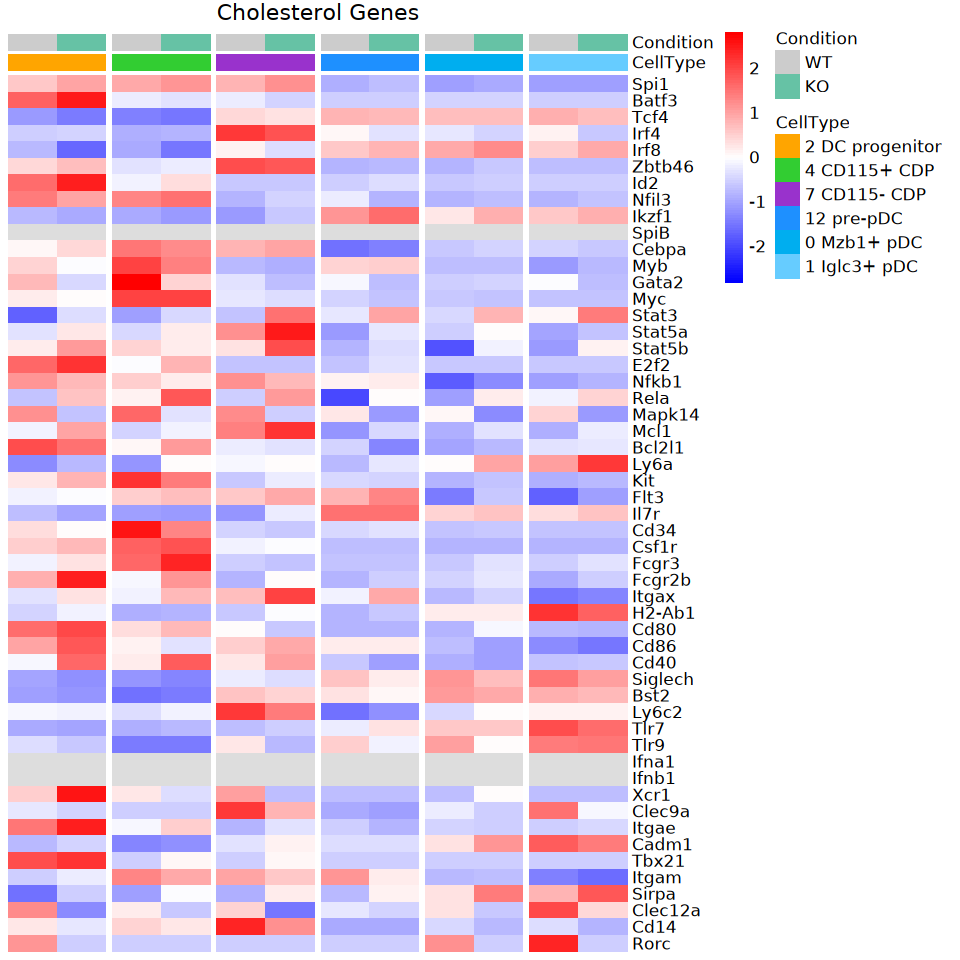

In [3]:
genes_of_interest <- c(

  # =========================================================================
  # 1. 核心转录因子 (Key Transcription Factors)
  # 按重要性、谱系和功能进行分组
  # =========================================================================

  # 1.1 谱系决定性主导转录因子 (Lineage-Defining Master Regulators)
  "Spi1",    # PU.1, 髓系及DC谱系早期主导因子，调控Flt3, Irf8等
  "Batf3",   # BATF3, cDC1谱系绝对核心决定因子
  "Tcf4",    # E2-2, pDC谱系绝对核心决定因子
  "Irf4",    # IRF4, cDC2谱系核心决定因子
  "Irf8",    # IRF8, cDC1和pDC发育共同的关键因子

  # 1.2 关键协同与上游调控因子 (Key Co-factors & Upstream Regulators)
  "Zbtb46",  # ZBTB46, 维持cDC身份的标志性因子
  "Id2",     # ID2, cDC1发育的关键正向调控因子
  "Nfil3",   # E4BP4, cDC1发育的上游关键调控因子 (调控Id2)
  "Ikzf1",   # Ikaros, DC发育早期(CDP)关键因子
  "SpiB",    # Spi-B, pDC发育的关键协同因子
  "Cebpa",   # C/EBPα, 髓系祖细胞分化关键因子
  "Myb",     # c-Myb, 造血干/祖细胞自我更新与分化
  "Gata2",   # GATA2, 早期造血调控因子

  # 1.3 增殖、存活与成熟调控因子 (Proliferation, Survival & Maturation Regulators)
  "Myc",     # c-Myc, Flt3L驱动的DC祖细胞增殖核心因子
  "Stat3",   # STAT3, Flt3L信号通路关键转导者，促进增殖/存活
  "Stat5a",  # STAT5A, Flt3L信号通路成员
  "Stat5b",  # STAT5B, Flt3L信号通路成员
  "E2f2",    # E2F2, 细胞周期调控因子
  "Nfkb1",   # NF-κB p50, DC成熟与炎症反应关键通路
  "Rela",    # RelA/p65, NF-κB通路核心成员
  "Mapk14",  # p38a, p38 MAPK信号通路, 参与DC功能与应激
  "Mcl1",    # Mcl-1, STAT3下游关键抗凋亡蛋白
  "Bcl2l1",  # Bcl-xL, 另一个关键抗凋亡蛋白

  # =========================================================================
  # 2. 祖细胞与前体细胞标志物 (Progenitor & Precursor Markers)
  # =========================================================================
  "Ly6a",    # Sca-1, HSC, MPP标志物
  "Kit",     # CD117 / c-Kit, HSC, MPP, CMP, CDP标志物 (Kitl是其配体)
  "Flt3",    # CD135 / Flt3, MPP, LMPP, CDP标志物，DC发育关键受体
  "Il7r",    # CD127 / IL7R, CLP标志物
  "Cd34",    # CD34, HSC, MPP标志物
  "Csf1r",   # CD115 / M-CSFR, MDP (巨噬细胞-DC祖细胞)标志物
  "Fcgr3",   # CD16, FcγRIII, 常与CD32联用
  "Fcgr2b",  # CD32, FcγRIIb, 常与CD16联用

  # =========================================================================
  # 3. 成熟DC亚群及功能标志物 (Mature DC Subsets & Functional Markers)
  # =========================================================================
  
  # 3.1 通用/经典DC标志物 (General / Conventional DC Markers)
  "Itgax",   # CD11c, DC最经典的标志物
  "H2-Ab1",  # MHC-II (I-A/I-E), 抗原呈递分子
  "Cd80",    # CD80, 共刺激分子
  "Cd86",    # CD86, 共刺激分子
  "Cd40",    # CD40, 共刺激/活化分子

  # 3.2 pDC (浆细胞样DC) 标志物
  "Siglech", # Siglec-H, pDC最特异的标志物之一
  "Bst2",    # CD317 / BST2 / Tetherin, pDC高表达
  "Ly6c2",   # Ly6C, pDC高表达 (注意Ly6c1和Ly6c2常一起被抗体识别)
  "Tlr7",    # TLR7, pDC识别病毒ssRNA的关键受体
  "Tlr9",    # TLR9, pDC识别细菌/病毒CpG DNA的关键受体
  "Ifna1",   # IFN-α, pDC产生的标志性I型干扰素
  "Ifnb1",   # IFN-β, pDC产生的标志性I型干扰素

  # 3.3 cDC1 标志物
  "Xcr1",    # XCR1, cDC1最特异的标志物
  "Clec9a",  # DNGR-1 / CD370, cDC1特异，识别坏死细胞
  "Itgae",   # CD103, 组织驻留型cDC1标志物 (如肠道、皮肤)
  "Cadm1",   # CADM1, cDC1表面分子
  "Tbx21",   # T-bet, 部分cDC1表达，驱动Th1应答

  # 3.4 cDC2 标志物
  "Itgam",   # CD11b, cDC2经典标志物
  "Sirpa",   # CD172a, cDC2标志物
  "Clec12a", # CD371, cDC2标志物
  "Cd14",    # CD14, 部分cDC2表达 (尤其在炎症状态)
  "Rorc"    # RORγt, 部分cDC2表达，驱动Th17应答
)

# 定义你想要分析的特定细胞类型
# 确保这些名称与 Seurat 对象中 'celltype' metadata 列的值完全匹配
selected_clusters <- c(
   "2 DC progenitor",
  "4 CD115+ CDP", 
  "7 CD115- CDP",

  "12 pre-pDC",
  "0 Mzb1+ pDC",
  "1 Iglc3+ pDC"
)

# 定义条件的顺序，这将决定热图中列的分组和排列顺序
# 确保这些名称与 Seurat 对象中 'orig.ident' metadata 列的值完全匹配
condition_order <- c("WT", "KO")

# --- 4. 数据准备 ---
# 从完整 Seurat 对象中筛选出只包含选定细胞类型的子集
# 这样可以减小后续计算的内存和时间开销
seu_subset <- subset(seu, subset = celltype %in% selected_clusters)

# 确保 'orig.ident' 列是因子 (factor) 类型，并且其水平 (levels) 按照我们定义的顺序排列
# 这对于后续 pheatmap 的列排序和注释条的顺序至关重要
seu_subset$orig.ident <- factor(seu_subset$orig.ident, levels = condition_order)

# --- 5. 计算平均表达矩阵 ---
# 初始化一个数值矩阵，用于存储计算得到的平均表达值
# 行是基因 (来自 genes_of_interest)
# 列是 "细胞类型_条件" 的所有组合
avg_expr <- matrix(0, nrow = length(genes_of_interest),
                  ncol = length(selected_clusters) * length(condition_order))

# 创建矩阵的列名，格式为 "细胞类型名称_条件名称"
# 例如 "14 M2-like CD163+ Mac_WT", "14 M2-like CD163+ Mac_KO", ...
column_names <- c()
# 使用嵌套循环生成所有组合的列名
for(cell_type in selected_clusters) {
  for(condition in condition_order) {
    column_names <- c(column_names, paste0(cell_type, "_", condition))
  }
}
# 将生成的列名赋给矩阵
colnames(avg_expr) <- column_names
# 将基因列表赋给矩阵的行名
rownames(avg_expr) <- genes_of_interest

# 核心计算部分：循环遍历每种细胞类型和条件，计算平均表达
col_index <- 1 # 初始化列索引，用于填充 avg_expr 矩阵
for(cell_type in selected_clusters) {
  for(condition in condition_order) {
    # 查找当前循环对应的细胞类型和条件的细胞 barcodes/ID
    # WhichCells 会返回符合条件的细胞名称向量
    cells <- WhichCells(seu_subset, expression = celltype == cell_type & orig.ident == condition)

    # 检查是否找到了符合条件的细胞
    if(length(cells) > 0) {
      # *** Seurat v5 修正点 ***
      # 直接从默认 Assay (assay_name) 的 'data' 层获取标准化表达数据
      # 'data' 层通常包含 LogNormalized 的数据，适合计算平均表达
      # LayerData 返回一个矩阵 (或 dgCMatrix)，行是基因，列是细胞
      # 使用 drop = FALSE 确保即使只选择一个基因或一个细胞，结果仍然是矩阵格式，防止维度降低
      # 只提取感兴趣的基因 (genes_of_interest) 和当前组合的细胞 (cells)
      # 使用 tryCatch 或检查 gene 是否存在可以增加代码稳健性，但这里假设基因存在于对象中
      # 检查感兴趣的基因是否都在 'data' 层的行名中 (可选但更安全)
      genes_present <- intersect(genes_of_interest, rownames(LayerData(seu_subset, assay = assay_name, layer = "data")))
      if (length(genes_present) == 0) {
          warning(paste("警告：在组合", cell_type, "_", condition,"中，感兴趣的基因均未在 'data' 层找到。该列将为 0。"))
          avg_expr[, col_index] <- 0
      } else {
          # 获取这些存在基因在指定细胞上的表达数据
          cell_data <- LayerData(seu_subset, assay = assay_name, layer = "data")[genes_present, cells, drop = FALSE]

          # 计算每个基因 (行) 在这些细胞中的平均表达值
          # 使用 na.rm = TRUE 忽略可能存在的 NA 值 (虽然在标准 Seurat 流程中 'data' 层通常不含 NA)
          # 将计算得到的平均值填充到 avg_expr 矩阵的对应位置
          # 只对在 cell_data 中实际存在的基因进行计算和赋值
          avg_expr[rownames(cell_data), col_index] <- rowMeans(cell_data, na.rm = TRUE)

          # 对于原始 genes_of_interest 中但不在当前 subset 的 'data' 层 rownames 中的基因 (理论上不应发生，除非 seu_subset 过滤掉了所有表达这些基因的细胞)，
          # 它们在 avg_expr 中将保持初始值 0
          genes_missing_in_layer <- setdiff(genes_of_interest, genes_present)
          if(length(genes_missing_in_layer) > 0){
               avg_expr[genes_missing_in_layer, col_index] <- 0 # 明确设为 0 (或 NA)
          }
      }

    } else {
      # 如果没有找到符合当前细胞类型和条件组合的细胞
      # 将该列的平均表达值设为 0 (或者可以设为 NA, 取决于你希望如何处理)
      warning(paste("警告：未找到细胞用于组合:", cell_type, "_", condition, "。该列将为 0。"))
      avg_expr[, col_index] <- 0
    }
    # 移动到矩阵的下一列
    col_index <- col_index + 1
  }
}


# --- 6. 创建热图注释信息 ---
# 创建一个数据框用于 pheatmap 的列注释 (annotation_col)
# 行名必须与 avg_expr 的列名完全一致且顺序相同

# 生成细胞类型注释列：重复每个细胞类型名称 length(condition_order) 次
cell_type_annot <- rep(selected_clusters, each = length(condition_order))
# 生成条件注释列：重复条件顺序列表 length(selected_clusters) 次
condition_annot <- rep(condition_order, times = length(selected_clusters))

# 合并成注释数据框
annotation_col <- data.frame(
  # 将注释列转换为因子，并指定水平顺序，确保注释条的颜色和顺序正确
  CellType = factor(cell_type_annot, levels = selected_clusters),
  Condition = factor(condition_annot, levels = condition_order),
  # 设置数据框的行名，必须与 avg_expr 的列名匹配
  row.names = column_names
)

# 定义注释条的颜色
# 为细胞类型分配颜色 (确保颜色数量和名称与 selected_clusters 匹配)
cell_type_colors <- c(
  "2 DC progenitor"                   = "#FFA500",  # 亮橙色
  "4 CD115+ CDP"                          = "#32CD32",  # 酸橙绿
  "7 CD115- CDP"                          = "#9932CC",  # 暗兰花紫 (保持紫色系但更鲜明)
  "12 pre-pDC"                = "#1E90FF",
   "0 Mzb1+ pDC"                                 = "#00AEEF",  # 明亮的天蓝色 (pDC系列1)
  "1 Iglc3+ pDC"                       = "#66CCFF"  # 更浅的天蓝色 (pDC系列2)
)
# 检查颜色名称是否与 selected_clusters 完全匹配
if (!all(selected_clusters %in% names(cell_type_colors))) {
    warning("细胞类型名称与颜色定义不完全匹配！请检查 cell_type_colors。")
}

# 为条件分配颜色 (确保颜色数量和名称与 condition_order 匹配)
condition_colors <- c(
  "WT" = "#CCCCCC",      # 浅灰色
  "KO" = "#66C2A5"   # 浅绿色 (来自 ColorBrewer Set2)
)
# 检查颜色名称是否与 condition_order 完全匹配
if (!all(condition_order %in% names(condition_colors))) {
    warning("条件名称与颜色定义不完全匹配！请检查 condition_colors。")
}


# 将颜色列表组合成 pheatmap 函数需要的格式 (一个命名列表)
annotation_colors <- list(
  CellType = cell_type_colors,
  Condition = condition_colors
)

# --- 7. 绘制热图 ---
# 计算在热图中添加列分割线的位置
# 分割线应该出现在每个细胞类型组之后
# 每个细胞类型组包含 length(condition_order) 列
gap_positions <- c()
# 在前 N-1 个细胞类型组后添加分割线
for (i in 1:(length(selected_clusters)-1)) {
  gap_positions <- c(gap_positions, i * length(condition_order))
}

# 创建颜色映射方案，用于热图主体
# 这里使用蓝-白-红调色板，通常用于表示 Z-score 化的表达量
# 蓝色表示相对低表达，白色表示接近平均水平，红色表示相对高表达
my_colors <- colorRampPalette(c("blue", "white", "red"))(100) # 生成100个渐变色

options(repr.plot.width = 8, repr.plot.height = 8)
tryCatch({
  pheatmap(avg_expr,
           cluster_rows = FALSE,         # 不对行（基因）进行聚类，保持 genes_of_interest 的顺序
           cluster_cols = FALSE,         # 不对列（细胞类型_条件组合）进行聚类，保持我们定义的顺序
           color = my_colors,            # 使用定义的蓝-白-红颜色映射
           fontsize_row = 10,            # 设置行标签（基因名）的字体大小 (根据需要调整)
           fontsize_col = 8,             # 设置列标签（如果显示的话）的字体大小 (通常不显示)
           annotation_col = annotation_col, # 添加列注释条 (细胞类型和条件)
           annotation_colors = annotation_colors, # 指定注释条使用的颜色
           main = "Cholesterol Genes", # 设置热图的主标题
           gaps_col = gap_positions,     # 在指定的列位置添加垂直分割线，用于分隔不同的细胞类型
           show_colnames = FALSE,        # 不显示列名 (因为列名很长，注释条已提供信息)
           border_color = NA,            # 不显示单元格边框 (NA 表示不显示，也可以设为 "grey" 等)
           scale = "row"                 # 对行进行 Z-score 标准化 (非常重要！)
                                         # 这使得不同表达水平的基因在同一颜色标度下具有可比性
                                         # 计算方式：(value - row_mean) / row_sd
          )
}, error = function(e) {
  # 如果 pheatmap 出错，打印错误信息并显示 avg_expr 矩阵的内容以便调试
  print("绘制热图时发生错误:")
  print(e)
  print("检查计算出的 avg_expr 矩阵:")
  print(head(avg_expr))
  print(summary(as.vector(avg_expr)))
})